In [2]:
import h5py
import numpy as np
import subprocess

name_planet= "TOI-776_b"

In [116]:


input_file = f'./{name_planet}/outputs/{name_planet}_assignment3_taskB_spectrum.h5'
output_file = f'./{name_planet}/outputs/{name_planet}_observed_spectrum.dat'

FIXED_ERROR = 1e-5

with h5py.File(input_file, 'r') as f:
    wl = f['Output/Spectra/native_wlgrid'][:]
    spectrum = f['Output/Spectra/native_spectrum'][:]

    # Fixed absolute uncertainty
    noise = np.full_like(spectrum, FIXED_ERROR)

    np.random.seed(42)
    observed_spectrum = spectrum + np.random.normal(0, noise)

    data = np.column_stack([wl, observed_spectrum, noise])

    np.savetxt(
        output_file,
        data,
        fmt='%.8e',
        header='wavelength(um) transit_depth error'
    )

print(f"✓ Created: {output_file}")
print(f"Wavelength range: {wl.min():.3f} - {wl.max():.3f} microns")
print(f"Number of points: {len(wl)}")
print(f"Fixed error used: {FIXED_ERROR}")


✓ Created: ./outputs/TOI-776_b_observed_spectrum.dat
Wavelength range: 0.300 - 50.002 microns
Number of points: 76744
Fixed error used: 1e-05


In [147]:



print("Running retrieval...")


subprocess.run([
    "taurex", 
    "-i", f"{name_planet}_transmission.par", "-S", f"{name_planet}_transmission_retrival.par",
    "--plot",
    "--retrieval"
])



Running retrieval...


taurex - INFO - TauREx 3.3.0
taurex - INFO - TauREx PROGRAM START AT 2025-12-23 20:37:02.173827
taurex.ParamParser - INFO - Interpolation mode set to linear
taurex.ParamParser - WARNING - Xsecs will be loaded in memory
taurex.ParamParser - WARNING - Radis is disabled
taurex.ParamParser - WARNING - Radis default grid will be used
taurex.ClassFactory - INFO - Reloading all modules and plugins
taurex.ClassFactory - INFO - ----------Plugin loading---------
taurex.TransmissionModel - INFO - Building model........
taurex.TransmissionModel - INFO - Collecting paramters
taurex.TransmissionModel - INFO - Setting up profiles
taurex.TransmissionModel - INFO - Setting up contributions
taurex.TransmissionModel - INFO - DONE
taurex.TransmissionModel - INFO - Computing pressure profile
taurex.ChemistryModel - INFO - Initializing chemistry model
taurex.OpacityCache - INFO - Reading opacity H2O
taurex.OpacityCache - INFO - Loading opacity H2O into model
taurex.OpacityCache - INFO - Reading opacity CH4


it=   464 logz=763409.8417385148

/root/anaconda3/lib/python3.13/site-packages/nestle.py:206: RuntimeWarning: divide by zero encountered in scalar divide
  cov = wsum / (wsum**2 - w2sum) * np.einsum('i,ij,ik', weights, dx, dx)
/root/anaconda3/lib/python3.13/site-packages/nestle.py:206: RuntimeWarning: invalid value encountered in multiply
  cov = wsum / (wsum**2 - w2sum) * np.einsum('i,ij,ik', weights, dx, dx)
taurex.Nestle - INFO - Sampling time 1150.627879858017 s
taurex.Nestle - INFO - Post-processing - Generating spectra and profiles
taurex.Nestle - INFO - Computing solution 0
taurex.TransmissionModel - INFO - Computing pressure profile
taurex.ChemistryModel - INFO - Initializing chemistry model
taurex.Absorption - INFO - Using cross-sections? True
taurex.Absorption - INFO - Recomputing active gas H2O opacity
taurex.Absorption - INFO - Recomputing active gas CH4 opacity
taurex.Absorption - INFO - Recomputing active gas CO2 opacity
taurex.Absorption - INFO - Recomputing active gas CO opacity
taurex.Absorption - INFO

niter: 465
ncall: 914
nsamples: 545
logz: 773491.718 +/-  0.357
h: 10.195


Traceback (most recent call last):
  File "/root/anaconda3/bin/taurex", line 8, in <module>
    sys.exit(main())
             ~~~~^^
  File "/root/anaconda3/lib/python3.13/site-packages/taurex/taurex.py", line 636, in main
    solution = optimizer.fit(output_size=output_size)
  File "/root/anaconda3/lib/python3.13/site-packages/taurex/optimizer/optimizer.py", line 539, in fit
    solution = self.generate_solution(output_size=output_size)
  File "/root/anaconda3/lib/python3.13/site-packages/taurex/optimizer/optimizer.py", line 702, in generate_solution
    profile_dict, spectrum_dict = self.generate_profiles(
                                  ~~~~~~~~~~~~~~~~~~~~~~^
        solution, self._observed.wavenumberGrid
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/root/anaconda3/lib/python3.13/site-packages/taurex/optimizer/optimizer.py", line 653, in generate_profiles
    return self._model.compute_error(
           ~~~~~~~~~~~~~~~~~~~~~~~~~^
        sample_iter, wngri


Checking for output files:
  ✗ No output files found

All files in outputs:
    ./outputs/TOI-776_b_assignment3_taskB_spectrum.dat
    ./outputs/TOI-776_b_observed_spectrum.dat
    ./outputs/TOI-776_b_assignment3_taskB_spectrum.png
    ./outputs/TOI-776_b_assignment3_taskB_spectrum.h5


In [28]:
filename = f"./{name_planet}/{name_planet}_transmission_retrival.dat"

# Load header (parameter names)
with open(filename, "r") as f:
    for line in f:
        if line.startswith("#"):
            header = line[1:].strip().split()
        else:
            break

# Load numerical samples
samples = np.loadtxt(filename)

param_names = ['planet_radius','T','H20', 'loglike']

print(f)

<_io.TextIOWrapper name='./TOI-776_b/TOI-776_b_transmission_retrival.dat' mode='r' encoding='UTF-8'>


planet_radius : {'median': np.float64(3.8730485249999997), 'mean': np.float64(9.71509493228324), 'minus': np.float64(3.1928755170399996), 'plus': np.float64(18.180906410999995)}
T : {'median': np.float64(0.0003316885866914369), 'mean': np.float64(0.00033612118490361877), 'minus': np.float64(1.568309012580987e-05), 'plus': np.float64(2.680558898262371e-05)}


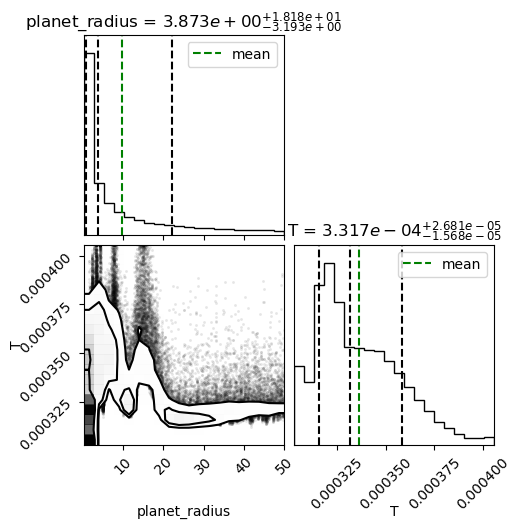

In [41]:
import numpy as np
import corner
import matplotlib.pyplot as plt


samples_var = samples[:, 0:2]
param_names_var = ['planet_radius', 'T']  #didn't put H2O cause in this case column is zero

# Compute statistics for each parameter
results = {}
for i, name in enumerate(param_names_var):
    q16, q50, q84 = np.percentile(samples_var[:, i], [16, 50, 84])
    mean = np.mean(samples_var[:, i])
    results[name] = {
        "median": q50,
        "mean": mean,
        "minus": q50 - q16,
        "plus": q84 - q50
    }
    print(name, ":", results[name])


fig = corner.corner(
    samples_var,
    labels=param_names_var,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".3e"
)

# Overlay mean as vertical lines
axes = np.array(fig.axes).reshape((len(param_names_var), len(param_names_var)))
for i, name in enumerate(param_names_var):
    mean_val = results[name]['mean']
    ax = axes[i, i]
    ax.axvline(mean_val, color='green', linestyle='--', label='mean')
    ax.legend()

plt.show()



In [30]:
results = {}

for i, name in enumerate(param_names):
    q16, q50, q84 = np.percentile(samples[:, i], [16, 50, 84])
    results[name] = {
        "median": q50,
        "minus": q50 - q16,
        "plus": q84 - q50
    }
    print(name,":", results[name])



planet_radius : {'median': np.float64(3.8730485249999997), 'minus': np.float64(3.1928755170399996), 'plus': np.float64(18.180906410999995)}
T : {'median': np.float64(0.0003316885866914369), 'minus': np.float64(1.568309012580987e-05), 'plus': np.float64(2.680558898262371e-05)}
H20 : {'median': np.float64(0.0), 'minus': np.float64(0.0), 'plus': np.float64(0.0)}
loglike : {'median': np.float64(0.0002581949998141145), 'minus': np.float64(0.00021285141987122217), 'plus': np.float64(0.0012120169949866966)}


In [44]:
#TXT FILE CREATOR    NB: CHANGE EVERY TIME 

with open(f"./{name_planet}/assignment3_{name_planet}_taskD.txt", "w") as f:
    f.write("ASSIGNMENT 3 – TASK D\n\n")

    f.write("FIXED PARAMETERS\n")
    f.write("----------------\n")
    f.write("H2O = 0.0 (fixed; posterior shows zero variance)\n\n")

    f.write("RETRIEVED PARAMETERS\n")
    f.write("--------------------\n")
    f.write(f"planet_radius = {results['planet_radius']['median']:.4f}  +{results['planet_radius']['plus']:.4f}  -{results['planet_radius']['minus']:.4f}\n")
    f.write(f"T              = {results['T']['median']:.4e}  +{results['T']['plus']:.4e}  -{results['T']['minus']:.4e}\n\n")

